In [11]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(root="./my_room_dataset", transform=data_transforms)

print("클래스 매핑 결과:", dataset.class_to_idx)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(f"총 {len(dataset)}장의 사진이 로드 되었습니다.")

클래스 매핑 결과: {'clean': 0, 'dirty': 1}
총 2181장의 사진이 로드 되었습니다.


=== 데이터셋 형태 확인 ===
이미지 텐서 형태: torch.Size([32, 3, 256, 256])
정답 라벨 형태: torch.Size([32])
첫 4장의 정답: tensor([1, 0, 0, 2])


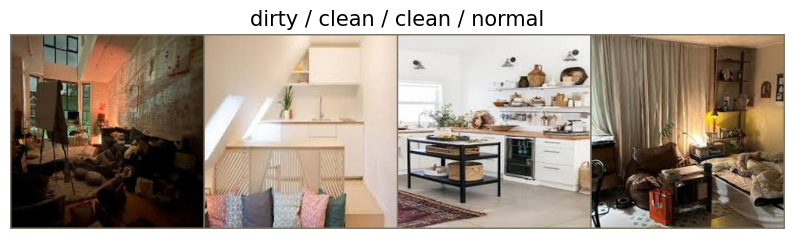

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

# ---------------------------------------------------------
# 1. 메모리에서 딱 한 묶음(1 Batch)의 데이터만 뽑아오기
# ---------------------------------------------------------
# next(iter())를 사용하면 dataloader에서 32장(설정한 batch_size)을 꺼내옵니다.
images, labels = next(iter(dataloader))

# 데이터의 형태(Shape) 확인하기
print("=== 데이터셋 형태 확인 ===")
print(f"이미지 텐서 형태: {images.shape}") 
# 결과 예시: torch.Size([32, 3, 224, 224])
# 해석: [배치 크기(32장), 색상 채널(3=RGB), 세로(224), 가로(224)]

print(f"정답 라벨 형태: {labels.shape}") 
# 결과 예시: torch.Size([32])
# 해석: 32장의 사진에 대한 정답(0 또는 1)이 들어있음

print(f"첫 4장의 정답: {labels[:4]}") 
# ---------------------------------------------------------


# ---------------------------------------------------------
# 2. 텐서를 다시 사람이 볼 수 있는 이미지로 변환해서 화면에 띄우기
# ---------------------------------------------------------
def imshow(tensor_img, title=None):
    """파이토치 텐서를 Matplotlib 이미지로 변환하여 보여주는 함수"""
    # 1) 파이토치(C, H, W) -> Matplotlib(H, W, C) 차원 순서 변경
    image = tensor_img.numpy().transpose((1, 2, 0))
    
    # 2) 정규화(Normalize) 해제하기 (원래 색상으로 되돌리기)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    
    # 3) 픽셀 값을 0~1 사이로 안전하게 자르기
    image = np.clip(image, 0, 1)
    
    # 4) 화면에 출력!
    plt.figure(figsize=(10, 5))
    plt.imshow(image)
    if title is not None:
        plt.title(title, fontsize=15)
    plt.axis('off') # 축 눈금 숨기기
    plt.show()

# 32장 중 앞의 4장만 나란히 붙여서 한 장의 그리드 이미지로 만들기
out_grid = torchvision.utils.make_grid(images[:4])

# 클래스 이름 가져오기 (예: ['clean', 'dirty'])
class_names = dataset.classes 

# 4장의 정답 라벨을 글자로 변환 (예: 'clean', 'dirty', 'dirty', 'clean')
title_list = [class_names[x] for x in labels[:4]]

# 화면에 출력!
imshow(out_grid, title=" / ".join(title_list))

In [17]:
import torch

print("데이터를 하나의 파일로 뭉치는 중입니다. 잠시만 기다려주세요...")

all_images = []
all_labels = []

# dataloader에서 변환된 이미지와 라벨을 전부 다 꺼내오기
for images, labels in dataloader:
    all_images.append(images)
    all_labels.append(labels)

# 리스트에 담긴 조각(배치)들을 하나의 거대한 텐서로 합치기
# 결과: [전체 사진 개수, 3, 224, 224] 형태가 됨
all_images = torch.cat(all_images, dim=0)
all_labels = torch.cat(all_labels, dim=0)

# 파이토치 전용 파일(.pt)로 딕셔너리 형태로 묶어서 저장!
torch.save({'images': all_images, 'labels': all_labels}, 'room_dataset.pt')

print("✅ room_dataset.pt 저장 완료! 이 파일을 팀원들에게 주면 됩니다.")

데이터를 하나의 파일로 뭉치는 중입니다. 잠시만 기다려주세요...
✅ room_dataset.pt 저장 완료! 이 파일을 팀원들에게 주면 됩니다.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

# ⭐️ 1. 사용할 장치(Device) 설정: GPU(CUDA)가 있으면 'cuda', 없으면 'cpu'로 자동 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 현재 학습에 사용되는 장치: {device}")

# =========================================================
# 1. 데이터 전처리 및 로드
# =========================================================
data_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 폴더에서 전체 데이터 읽어오기 (경로는 환경에 맞게 유지)
full_dataset = datasets.ImageFolder(root='./my_room_dataset', transform=data_transforms)

# =========================================================
# 2. Train / Test Split (학습용 80% : 시험용 20%)
# =========================================================
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

# random_split으로 데이터 무작위 분할!
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

# 각각의 DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"📊 총 데이터: {len(full_dataset)}장 | 학습용: {train_size}장 | 시험용: {test_size}장")

# =========================================================
# 3. Custom CNN 모델 정의
# =========================================================
print("📥 ResNet18 모델의 뇌(가중치)를 다운로드하는 중...")

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# ⭐️ 2. 모델을 위에서 설정한 장치(GPU)로 통째로 이동!
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# =========================================================
# 4. 본격적인 학습 (Training) 및 평가 (Testing) 루프
# =========================================================
epochs = 20

print(f"\n🚀 [{device}] 환경에서 ResNet 전이 학습을 시작합니다!")
for epoch in range(epochs):
    # ---------- [학습 단계] ----------
    model.train()
    running_loss = 0.0
    
    for inputs, labels in train_loader:
        # ⭐️ 3. 학습용 이미지 데이터와 정답 라벨도 장치(GPU)로 이동!
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    avg_train_loss = running_loss / len(train_loader)
    
    # ---------- [평가 단계] ----------
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            # ⭐️ 4. 평가용 이미지 데이터와 정답 라벨도 장치(GPU)로 이동!
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    test_accuracy = 100 * correct / total
    print(f"[{epoch + 1}/{epochs} 에폭] Train 오차: {avg_train_loss:.4f} | Test 정답률: {test_accuracy:.2f}%")

# 새로운 가중치 저장하기!
torch.save(model.state_dict(), 'resnet_room_clean_model.pth')
print("✨ ResNet 모델 학습 및 저장(resnet_room_clean_model.pth) 완료!")

🖥️ 현재 학습에 사용되는 장치: cuda
📊 총 데이터: 2181장 | 학습용: 1744장 | 시험용: 437장
📥 ResNet18 모델의 뇌(가중치)를 다운로드하는 중...

🚀 [cuda] 환경에서 ResNet 전이 학습을 시작합니다!
[1/30 에폭] Train 오차: 0.1809 | Test 정답률: 94.74%
[2/30 에폭] Train 오차: 0.0258 | Test 정답률: 94.51%
[3/30 에폭] Train 오차: 0.0162 | Test 정답률: 94.74%
[4/30 에폭] Train 오차: 0.0082 | Test 정답률: 95.65%
[5/30 에폭] Train 오차: 0.0027 | Test 정답률: 94.97%
[6/30 에폭] Train 오차: 0.0036 | Test 정답률: 94.28%
[7/30 에폭] Train 오차: 0.0019 | Test 정답률: 95.42%
[8/30 에폭] Train 오차: 0.0040 | Test 정답률: 93.82%
[9/30 에폭] Train 오차: 0.0066 | Test 정답률: 95.19%
[10/30 에폭] Train 오차: 0.0009 | Test 정답률: 95.42%
[11/30 에폭] Train 오차: 0.0010 | Test 정답률: 95.88%
[12/30 에폭] Train 오차: 0.0007 | Test 정답률: 95.19%
[13/30 에폭] Train 오차: 0.0011 | Test 정답률: 94.74%
[14/30 에폭] Train 오차: 0.0004 | Test 정답률: 95.19%
[15/30 에폭] Train 오차: 0.0056 | Test 정답률: 93.14%
[16/30 에폭] Train 오차: 0.0341 | Test 정답률: 91.53%
[17/30 에폭] Train 오차: 0.0375 | Test 정답률: 92.68%
[18/30 에폭] Train 오차: 0.0076 | Test 정답률: 95.42%
[19/30 에폭] Train 오차: 0.0022 

In [ ]:
# Keras 사용 모델 학습 코드

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import ResNet50 # Keras 공식 지원은 ResNet50부터입니다.
from tensorflow.keras.callbacks import EarlyStopping
# ResNet18을 꼭 쓰고 싶다면 분류 라이브러리인 classification_models를 쓰거나 ResNet50을 추천합니다.

print("🔥 현재 인식된 GPU 목록:", tf.config.list_physical_devices('GPU'))

# =========================================================
# 1. 데이터 전처리 및 로드 (ImageFolder 대신 image_dataset_from_directory)
# =========================================================
img_height, img_width = 256, 256
batch_size = 32

# 데이터셋을 자동으로 Train/Validation으로 나누어 로드합니다.
train_ds = tf.keras.utils.image_dataset_from_directory(
    './my_room_dataset',
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    './my_room_dataset',
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# ResNet 입력 규격에 맞는 전처리 (0~255 -> -1~1 혹은 ResNet 표준화)
normalization_layer = layers.Rescaling(1./255) # 혹은 ResNet50 전용 preprocess_input 사용
train_ds = train_ds.map(lambda x, y: (tf.keras.applications.resnet50.preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (tf.keras.applications.resnet50.preprocess_input(x), y))

# =========================================================
# 2. 모델 정의 (ResNet50 전이 학습)
# =========================================================
# Keras 공식 라이브러리는 ResNet18 대신 ResNet50이 기본입니다. (더 깊고 정확함)
base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

# 베이스 모델 가중치는 고정 (Freezing) - 학습되지 않게 함
base_model.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(3, activation='softmax') # 클래스가 3개이므로 Dense(3)
])

# =========================================================
# 3. 컴파일 및 학습
# =========================================================
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy', # PyTorch의 CrossEntropyLoss와 유사
    metrics=['accuracy']
)

# ⭐️ Early Stopping 콜백 정의
early_stopping = EarlyStopping(
    monitor='val_loss',        # 감시할 지표 (검증 세트의 오차)
    patience=3,                # 오차가 줄어들지 않아도 몇 번의 에폭(Epoch)을 더 참을 것인가?
    restore_best_weights=True  # 멈췄을 때, 가장 성능이 좋았던 시점의 가중치로 자동 복구! (매우 중요)
)

print("\n🚀 Keras ResNet 전이 학습을 시작합니다!")
epochs = 200
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

# =========================================================
# 4. 모델 저장 (H5 형식)
# =========================================================
model.save('resnet_room_clean_model.keras')
print("✨ Keras 모델 학습 및 저장(resnet_room_clean_model.keras) 완료!")

🔥 현재 인식된 GPU 목록: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Found 2181 files belonging to 2 classes.
Using 1745 files for training.
Found 2181 files belonging to 2 classes.
Using 436 files for validation.

🚀 Keras ResNet 전이 학습을 시작합니다!
Epoch 1/200
55/55 [==============================] - 5s 65ms/step - loss: 0.8816 - accuracy: 0.5427 - val_loss: 0.5240 - val_accuracy: 0.7477
Epoch 2/200
55/55 [==============================] - 3s 56ms/step - loss: 0.4161 - accuracy: 0.8321 - val_loss: 0.3444 - val_accuracy: 0.8624
Epoch 3/200
55/55 [==============================] - 3s 56ms/step - loss: 0.2950 - accuracy: 0.8946 - val_loss: 0.2726 - val_accuracy: 0.9151
Epoch 4/200
55/55 [==============================] - 3s 57ms/step - loss: 0.2389 - accuracy: 0.9209 - val_loss: 0.2371 - val_accuracy: 0.9243
Epoch 5/200
55/55 [==============================] - 4s 68ms/step - loss: 0.2059 - accuracy: 0.9312 - val_loss: 0.2126 - val_accuracy: 0.9358
Epoch 6/200
55/55 [============

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, models
from PIL import Image
import os # ★ 폴더 안의 파일들을 읽어오기 위해 추가!

# =========================================================
# 1~3단계: 모델 세팅 및 전처리 (기존과 100% 동일)
# =========================================================
model = models.resnet18() 
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model.load_state_dict(torch.load('resnet_room_clean_model.pth'))
model.eval()

data_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
classes = ['clean', 'dirty']

# =========================================================
# 4. ★ 수정된 부분: 폴더 안의 여러 사진 연속으로 테스트하기 ★
# =========================================================
# 테스트할 사진들이 모여있는 폴더 경로
test_folder = './test_images/normal' 

# 폴더 안에서 확장자가 jpg, jpeg, png인 파일들만 리스트로 묶어오기
image_files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"📂 '{test_folder}' 폴더에서 총 {len(image_files)}장의 이미지를 발견했습니다!\n")
print("=== 🤖 AI 판독 시작 ===")

# for문으로 사진을 한 장씩 꺼내서 판독!
for file_name in image_files:
    image_path = os.path.join(test_folder, file_name)
    
    try:
        img = Image.open(image_path).convert('RGB')
        input_tensor = data_transforms(img).unsqueeze(0)

        with torch.no_grad(): 
            outputs = model(input_tensor)
            
            probabilities = F.softmax(outputs, dim=1)[0]
            confidence = torch.max(probabilities).item() * 100
            
            _, predicted = torch.max(outputs, 1)
            result = classes[predicted.item()]
            
            # 보기 좋게 한 줄씩 결과 출력
            print(f"[{file_name}] ➡️ 판독 결과: {result} ({confidence:.1f}% 확신)")
            
    except Exception as e:
        print(f"[{file_name}] ❌ 이미지 처리 중 에러 발생: {e}")

print("\n✨ 모든 사진의 판독이 완료되었습니다!")

📂 './test_images/normal' 폴더에서 총 1072장의 이미지를 발견했습니다!

=== 🤖 AI 판독 시작 ===
[normal0001.jpg] ➡️ 판독 결과: clean (99.0% 확신)
[normal0002.jpg] ➡️ 판독 결과: clean (94.0% 확신)
[normal0003.jpg] ➡️ 판독 결과: clean (56.8% 확신)
[normal0004.jpg] ➡️ 판독 결과: dirty (51.5% 확신)
[normal0005.jpg] ➡️ 판독 결과: dirty (85.2% 확신)
[normal0006.jpg] ➡️ 판독 결과: dirty (50.3% 확신)
[normal0007.jpg] ➡️ 판독 결과: clean (87.9% 확신)
[normal0008.jpg] ➡️ 판독 결과: dirty (100.0% 확신)
[normal0009.jpg] ➡️ 판독 결과: clean (74.2% 확신)
[normal0010.jpg] ➡️ 판독 결과: clean (98.7% 확신)
[normal0011.jpg] ➡️ 판독 결과: clean (99.8% 확신)
[normal0012.jpg] ➡️ 판독 결과: dirty (100.0% 확신)
[normal0013.jpg] ➡️ 판독 결과: clean (100.0% 확신)
[normal0014.jpg] ➡️ 판독 결과: clean (65.1% 확신)
[normal0015.jpg] ➡️ 판독 결과: dirty (99.9% 확신)
[normal0016.jpg] ➡️ 판독 결과: clean (76.7% 확신)
[normal0017.jpg] ➡️ 판독 결과: clean (100.0% 확신)
[normal0018.jpg] ➡️ 판독 결과: dirty (99.9% 확신)
[normal0019.jpg] ➡️ 판독 결과: dirty (98.2% 확신)
[normal0020.jpg] ➡️ 판독 결과: dirty (96.2% 확신)
[normal0021.jpg] ➡️ 판독 결과: clean (100.0% 확신)

In [ ]:
import os
from PIL import Image

def resize_images(input_folder, output_folder, target_size):
    # 출력 폴더가 없으면 생성
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # 폴더 내 파일 목록 가져오기
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
            img_path = os.path.join(input_folder, filename)
            
            with Image.open(img_path) as img:
                # 해상도 변경 (LANCZOS 필터는 고화질 유지에 도움을 줍니다)
                resized_img = img.resize(target_size, Image.Resampling.LANCZOS)
                
                # 결과 저장
                resized_img.save(os.path.join(output_folder, filename))
                print(f"{filename} 변환 완료!")

# 사용 예시
input_dir = 'my_room_dataset/dirty'    # 원본 이미지가 들어있는 폴더명
output_dir = 'resized_images_dirty'    # 저장할 폴더명
target_resolution = (256, 256) # 변경하고 싶은 해상도 (가로, 세로)

resize_images(input_dir, output_dir, target_resolution)

In [ ]:
# Keras 사용 모델 검증 코드

import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# =========================================================
# 1. 모델 세팅
# =========================================================
# 아까 저장하셨던 모델 이름에 맞게 확장자(.h5 또는 .keras)를 적어주세요.
model_path = 'resnet_room_clean_model.keras' 
model = tf.keras.models.load_model(model_path)

# 폴더명 알파벳 순서대로 클래스가 매핑됩니다. (c가 먼저니까 clean이 0, dirty가 1)
classes = ['clean', 'dirty'] 

# =========================================================
# 2. 테스트할 폴더 및 파일 읽기
# =========================================================
test_folder = './test_images/normal' 
image_files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"📂 '{test_folder}' 폴더에서 총 {len(image_files)}장의 이미지를 발견했습니다!\n")
print("=== 🤖 Keras AI 판독 시작 ===")

# =========================================================
# 3. 폴더 안의 여러 사진 연속으로 테스트하기
# =========================================================
for file_name in image_files:
    image_path = os.path.join(test_folder, file_name)
    
    try:
        # ⭐️ Keras 내장 함수로 이미지를 부르고 크기를 맞춥니다 (256x256)
        img = image.load_img(image_path, target_size=(256, 256))
        
        # 이미지를 숫자 배열(Numpy Array)로 변환
        img_array = image.img_to_array(img)
        
        # 모델은 항상 '배치(묶음)' 단위로 받기 때문에 차원을 하나 추가합니다.
        # (256, 256, 3) ➡️ (1, 256, 256, 3)
        input_tensor = np.expand_dims(img_array, axis=0)
        
        # ⭐️ 학습할 때 썼던 ResNet50 전처리 방식을 똑같이 적용!
        input_tensor = tf.keras.applications.resnet50.preprocess_input(input_tensor)

        # 모델 예측 (verbose=0으로 하면 지저분한 진행바가 숨겨집니다)
        outputs = model.predict(input_tensor, verbose=0)
        
        # ⭐️ 결과 해석 및 확신도(Confidence) 계산
        # Keras 모델 마지막 레이어에 softmax를 썼기 때문에 outputs 값 자체가 이미 확률(0~1)입니다!
        probabilities = outputs[0]
        confidence = np.max(probabilities) * 100  # 제일 높은 확률을 100분율로 변환
        
        predicted_index = np.argmax(probabilities) # 0 아니면 1
        result = classes[predicted_index]
        
        # 보기 좋게 한 줄씩 결과 출력
        print(f"[{file_name}] ➡️ 판독 결과: {result} ({confidence:.1f}% 확신)")
        
    except Exception as e:
        print(f"[{file_name}] ❌ 이미지 처리 중 에러 발생: {e}")

print("\n✨ 모든 사진의 판독이 완료되었습니다!")